<a href="https://colab.research.google.com/github/inte22/A-lifr/blob/main/%5BColab%EC%97%85%EB%A1%9C%EB%93%9C%EC%9A%A9%5D%EC%86%8C%ED%94%84%ED%8A%B8%EC%9B%A8%EC%96%B4%ED%95%99%EA%B3%BC_202121040_%EC%97%AC%EC%98%81%EC%A4%80_%EC%8B%A4%EC%8A%B5Zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 Zero — 선형대수학

**선형대수학 관련 응용에 자주 쓰이는 기초 문법들**

- 담당 교수: 양희경
- 학과: 소프트웨어학과
- 학번: 202121040
- 이름: 여영준

## 실습 내용
0. Colab 접속 및 Jupyter notebook 사용법
1. 파이썬 기초 (Optional)
2. 벡터, 행렬 연산, 그래프 그리기

> **참고**: 강의자료의 코드는 Python 2 문법(`print x`)으로 작성되어 있으나,
> Colab은 Python 3 환경이므로 이 노트북은 모두 Python 3 문법(`print(x)`)으로 옮겨 작성했습니다.

---
# 0. Colab 접속 및 Jupyter notebook 사용법

## Colaboratory(Colab)란?
- **Google Colaboratory = Google Drive + Jupyter Notebook**
- Python 3 을 지원하는 Jupyter Notebook 의 구글 커스텀 버전
- *Jupyter Notebook*: 웹 브라우저에서 파이썬 코드를 작성하고 실행할 수 있는 개발 도구

## Colab 의 장점
- 구글 드라이브와 연동이 가능하다.
- GitHub 와 연동이 가능하다.
- GPU 가속을 무료로 받을 수 있다. (무료버전 12시간 제약)
- 협업이 가능하다.

## Colab 유의할 점
- 최대 세션 유지 시간은 **12시간** (데이터는 소멸되나 소스코드는 자동 저장됨)

## 사용 방법
1. Google 로그인 후 <https://colab.research.google.com/> 접속
2. `파일 → 새 노트`
3. 파일 이름을 클릭하여 이름 수정 (`Ctrl+S` 로 저장)
4. (Option) GPU 가속: `수정 → 노트 설정` (또는 `런타임 → 런타임 유형 변경`) → GPU 선택 → 저장
5. 구글 드라이브 내 `드라이브/Colab Notebooks` 폴더가 생성되었는지 확인

## Jupyter 작업물을 Colab 에서 사용할 경우
1. Jupyter 에서 `.ipynb` 로 다운로드한 파일을 Colab 폴더에 업로드
2. 우클릭 → `연결 앱 → Google Colaboratory` 로 열기

## 구글 드라이브 연동 방법
1. 왼쪽 폴더 아이콘 클릭
2. `드라이브 마운트` 클릭 → `Google Drive에 연결` 클릭
3. Colab 내에서 파일 경로는 `drive/MyDrive/…` 로 접근

아래 셀을 실행하면 인증 후 `drive/MyDrive/…` 로 접근할 수 있습니다.

## 참고 사이트
- Colab 명령어: <https://theorydb.github.io/dev/2019/08/23/dev-ml-colab/>
- GitHub 연동 방법: <https://league-cat.tistory.com/305>

In [2]:
# 구글 드라이브 연동 (Colab 전용)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 마운트 확인
import os
print('drive 마운트 여부:', os.path.isdir('/content/drive/MyDrive'))

drive 마운트 여부: True


---
# 1. 파이썬 기초 (Optional)

## 프린트

In [4]:
print("Hello, world")

# integer
x = 3
print("정수: %01d, %02d, %03d, %04d, %05d"
      % (x, x, x, x, x))

# float
x = 256.123
print("실수: %.0f, %.1f, %.2f"
      % (x, x, x))

# string
x = "Hello, world"
print("문자열: [%s]" % (x))

Hello, world
정수: 3, 03, 003, 0003, 00003
실수: 256, 256.1, 256.12
문자열: [Hello, world]


In [42]:
# 실행 환경 확인 (Colab 런타임)
import sys, platform
print("Python :", sys.version)
print("platform :", platform.platform())

Python : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
platform : Linux-6.6.122+-x86_64-with-glibc2.39


## 반복문, 조건문

In [5]:
contents = ["Regression", "Classification", "SVM", "Clustering", "Dimension reduction",
            "NN", "CNN", "AE", "GAN", "RNN"]
for con in contents:
    if con in ["Regression", "Classification", "SVM", "Clustering", "Dimension reduction"]:
        print("%s 은(는) 기계학습 내용입니다." % con)
    elif con in ["CNN"]:
        print("%s 은(는) convolutional neural network 입니다." % con)
    else:
        print("%s 은(는) 심층학습 내용입니다." % con)

Regression 은(는) 기계학습 내용입니다.
Classification 은(는) 기계학습 내용입니다.
SVM 은(는) 기계학습 내용입니다.
Clustering 은(는) 기계학습 내용입니다.
Dimension reduction 은(는) 기계학습 내용입니다.
NN 은(는) 심층학습 내용입니다.
CNN 은(는) convolutional neural network 입니다.
AE 은(는) 심층학습 내용입니다.
GAN 은(는) 심층학습 내용입니다.
RNN 은(는) 심층학습 내용입니다.


## 반복문과 인덱스

In [6]:
for (i, con) in enumerate(contents):
    print("[%d/%d]: %s" % (i, len(contents), con))

[0/10]: Regression
[1/10]: Classification
[2/10]: SVM
[3/10]: Clustering
[4/10]: Dimension reduction
[5/10]: NN
[6/10]: CNN
[7/10]: AE
[8/10]: GAN
[9/10]: RNN


## 함수

In [7]:
def sum(a, b):
    return a + b

x = 10.0
y = 20.0
print("%.1f + %.1f = %.1f" % (x, y, sum(x, y)))

10.0 + 20.0 = 30.0


## 리스트

In [8]:
a = []
b = [1, 2, 3]
c = ["Hello", ",", "world"]
d = [1, 2, 3, "x", "y", "z"]
x = []
print(x)

x.append('a')
print(x)

x.append(123)
print(x)

x.append(["a", "b"])
print(x)

[]
['a']
['a', 123]
['a', 123, ['a', 'b']]


## 딕셔너리(dictionary)

> Python 3.7 부터 딕셔너리는 **입력한 순서**를 그대로 유지합니다.
> (강의자료의 Python 2 출력과 키 순서가 다르게 보이는 것은 이 때문입니다.)

In [9]:
dic = dict()
dic["name"] = "Heekyung"
dic["town"] = "Goyang city"
dic["job"] = "Assistant professor"
print(dic)

{'name': 'Heekyung', 'town': 'Goyang city', 'job': 'Assistant professor'}


## 클래스

In [10]:
class Student:
    # 생성자
    def __init__(self, name):
        self.name = name

    # 메써드
    def study(self, hard=False):
        if hard:
            print("%s 학생은 열심히 공부합니다." % self.name)
        else:
            print("%s 학생은 공부합니다." % self.name)

s = Student('Heekyung')
s.study()
s.study(hard=True)

Heekyung 학생은 공부합니다.
Heekyung 학생은 열심히 공부합니다.


---
# 2. 벡터, 행렬 연산, 그래프 그리기

## 텐서(Tensor)와 랭크(Rank)

- **텐서(Tensor)**: 다차원 배열을 일반화한 것. Scalar, vector, matrix 등이 포함됨
- **랭크(Rank)**: 텐서의 차원

| Rank | 이름 | 예시 |
|---|---|---|
| Rank 0 tensor | Scalar | `3` |
| Rank 1 tensor | Vector | `[1, 2, 3]` |
| Rank 2 tensor | Matrix | `[[1, 2], [3, 4]]` |
| Rank n tensor | n차원 텐서 | … |

## 라이브러리(패키지) 로드

In [11]:
import numpy as np

## 프린트 함수 정의

In [12]:
def print_val(x):
    print("Type:", type(x))
    print("Shape:", x.shape)
    print("값:\n", x)
    print(" ")

## rank 1 np array

In [13]:
x = np.array([1, 2, 3])
print_val(x)

x[0] = 5
print_val(x)

Type: <class 'numpy.ndarray'>
Shape: (3,)
값:
 [1 2 3]
 
Type: <class 'numpy.ndarray'>
Shape: (3,)
값:
 [5 2 3]
 


## rank 2 np array

In [14]:
y = np.array([[1, 2, 3], [4, 5, 6]])
print_val(y)

Type: <class 'numpy.ndarray'>
Shape: (2, 3)
값:
 [[1 2 3]
 [4 5 6]]
 


## rank 2 zeros

In [15]:
a = np.zeros((2, 2))
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[0. 0.]
 [0. 0.]]
 


## rank 2 ones

In [16]:
a = np.ones((3, 2))
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (3, 2)
값:
 [[1. 1.]
 [1. 1.]
 [1. 1.]]
 


## rank 2 단위 행렬(identity matrix)

In [17]:
a = np.eye(3, 3)
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (3, 3)
값:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
 


## 랜덤 행렬 (uniform: 0~1 사이 모든 값들이 나올 확률이 같음)

In [18]:
a = np.random.random((4, 4))
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (4, 4)
값:
 [[0.36373192 0.11673021 0.21244868 0.34084645]
 [0.51278697 0.74196757 0.71356328 0.3307643 ]
 [0.39214985 0.91700596 0.87323182 0.96809801]
 [0.10966111 0.87012875 0.84727635 0.31026709]]
 


## 랜덤 행렬 (Gaussian: 0을 평균으로 하는 가우시안 분포를 따르는 랜덤값)

In [19]:
a = np.random.randn(4, 4)
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (4, 4)
값:
 [[ 0.42162375  0.70217551  1.23080512 -0.93488444]
 [-0.28702632 -0.3437708   1.44874923 -0.73291314]
 [ 0.51865373  1.03028142  0.93829895 -0.46325752]
 [ 1.0339409  -0.83131959 -1.02433775 -0.55225182]]
 


## np array indexing

In [20]:
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print_val(a)

Type: <class 'numpy.ndarray'>
Shape: (3, 4)
값:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
 


In [21]:
b = a[:2, 1:3]   # 행 0~1, 열 1~2
print_val(b)

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[2 3]
 [6 7]]
 


## 행렬의 n번째 행 얻기

In [22]:
row1 = a[1, :]   # 1번째 행
print_val(row1)

Type: <class 'numpy.ndarray'>
Shape: (4,)
값:
 [5 6 7 8]
 


## 행렬의 원소별 연산

In [23]:
m1 = np.array([[1, 2], [3, 4]], dtype=np.float64)
m2 = np.array([[5, 6], [7, 8]], dtype=np.float64)

In [24]:
# elementwise sum
print_val(m1 + m2)
print_val(np.add(m1, m2))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[ 6.  8.]
 [10. 12.]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[ 6.  8.]
 [10. 12.]]
 


In [25]:
# elementwise difference
print_val(m1 - m2)
print_val(np.subtract(m1, m2))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[-4. -4.]
 [-4. -4.]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[-4. -4.]
 [-4. -4.]]
 


In [26]:
# elementwise product
print_val(m1 * m2)
print_val(np.multiply(m1, m2))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[ 5. 12.]
 [21. 32.]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[ 5. 12.]
 [21. 32.]]
 


In [27]:
# elementwise division
print_val(m1 / m2)
print_val(np.divide(m1, m2))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[0.2        0.33333333]
 [0.42857143 0.5       ]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[0.2        0.33333333]
 [0.42857143 0.5       ]]
 


In [28]:
# elementwise square root
print_val(np.sqrt(m1))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[1.         1.41421356]
 [1.73205081 2.        ]]
 


## 행렬 연산

In [29]:
m1 = np.array([[1, 2], [3, 4]])   # (2,2)
m2 = np.array([[5, 6], [7, 8]])   # (2,2)
v1 = np.array([9, 10])            # (2,)
v2 = np.array([11, 12])           # (2,)

print_val(m1)
print_val(m2)
print_val(v1)
print_val(v2)

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[1 2]
 [3 4]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[5 6]
 [7 8]]
 
Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [ 9 10]
 
Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [11 12]
 


## 벡터-벡터 연산 (내적)

In [30]:
print_val(v1.dot(v2))
print_val(np.dot(v1, v2))

Type: <class 'numpy.int64'>
Shape: ()
값:
 219
 
Type: <class 'numpy.int64'>
Shape: ()
값:
 219
 


## 벡터-행렬 연산

In [31]:
print_val(m1.dot(v1))      # (2,2) x (2,1) -> (2,1)
print_val(np.dot(m1, v1))

Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [29 67]
 
Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [29 67]
 


## 행렬-행렬 연산

In [32]:
print_val(m1.dot(m2))
print_val(np.dot(m1, m2))

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[19 22]
 [43 50]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[19 22]
 [43 50]]
 


## 전치 행렬 (transpose)

In [33]:
print_val(m1)
print_val(m1.T)

Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[1 2]
 [3 4]]
 
Type: <class 'numpy.ndarray'>
Shape: (2, 2)
값:
 [[1 3]
 [2 4]]
 


## 합

In [34]:
print_val(np.sum(m1))          # 행렬의 모든 원소의 합
print_val(np.sum(m1, axis=0))  # shape[0] (행) 을 압축시키자. (2,2) -> (2,)
print_val(np.sum(m1, axis=1))  # shape[1] (열) 을 압축시키자. (2,2) -> (2,)

Type: <class 'numpy.int64'>
Shape: ()
값:
 10
 
Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [4 6]
 
Type: <class 'numpy.ndarray'>
Shape: (2,)
값:
 [3 7]
 


---
## ✏️ 실습 문제 — 빈칸 채우기 (강의자료 p.44)

아래 `(2, 3)` 행렬에 대해 `np.sum` 의 `axis` 값에 따른 **결과 shape 과 값**을 채워 넣으시오.

```python
m1 = np.array([[1,2,3], [4,5,6]])
print(np.sum(m1))
print(np.sum(m1, axis=0))   # shape[0] (행) 을 압축시키자. (2,3) -> (   ?   )
print(np.sum(m1, axis=1))   # shape[1] (열) 을 압축시키자. (2,3) -> (   ?   )
```

### 풀이

- `np.sum(m1)` : 모든 원소의 합 → 스칼라 **`21`**
- `np.sum(m1, axis=0)` : **행(axis 0)** 방향을 압축 → **`(2,3) -> (3,)`**
  - 열별 합: `[1+4, 2+5, 3+6]` = **`[5, 7, 9]`**
- `np.sum(m1, axis=1)` : **열(axis 1)** 방향을 압축 → **`(2,3) -> (2,)`**
  - 행별 합: `[1+2+3, 4+5+6]` = **`[6, 15]`**

> 정리: `axis=k` 는 **k번째 축을 없앤다(압축한다)** 는 뜻이므로,
> 결과의 shape 은 원래 shape 에서 k번째 원소를 뺀 것이 된다.

In [35]:
m1 = np.array([[1, 2, 3], [4, 5, 6]])
print(m1)
print(m1.shape)   # (2,3)

[[1 2 3]
 [4 5 6]]
(2, 3)


In [36]:
print(np.sum(m1))                        # 21
print(np.sum(m1, axis=0))                # (2,3) -> (3,)
print(np.sum(m1, axis=1))                # (2,3) -> (2,)

print()
print("np.sum(m1, axis=0).shape :", np.sum(m1, axis=0).shape)
print("np.sum(m1, axis=1).shape :", np.sum(m1, axis=1).shape)

21
[5 7 9]
[ 6 15]

np.sum(m1, axis=0).shape : (3,)
np.sum(m1, axis=1).shape : (2,)


## zeros-like

In [37]:
m1 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, 9],
               [10, 11, 12]])
m2 = np.zeros_like(m1)   # m1과 같은 형태의 0으로 이루어진 np array
print_val(m1)
print_val(m2)

Type: <class 'numpy.ndarray'>
Shape: (4, 3)
값:
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
 
Type: <class 'numpy.ndarray'>
Shape: (4, 3)
값:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]
 


---
## Matplot library

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

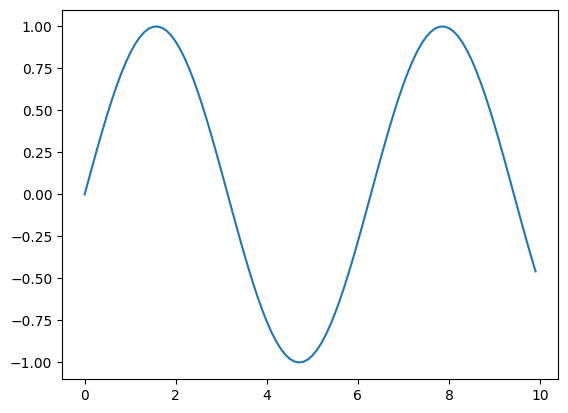

In [39]:
# sin 커브
x = np.arange(0, 10, 0.1)   # 0~10 까지 0.1 간격의 숫자 배열
y = np.sin(x)

plt.plot(x, y)
plt.show()

## 한 번에 두 개 그래프 그리기

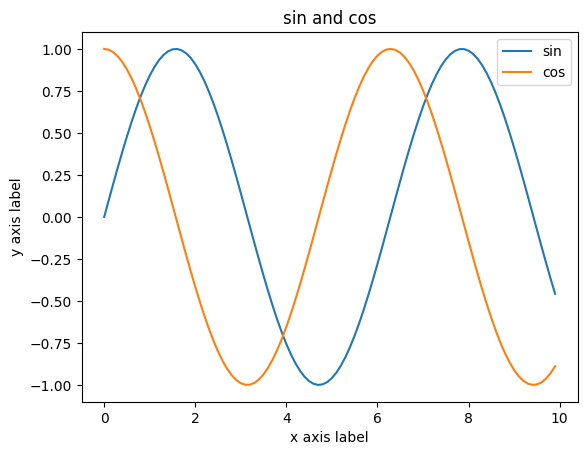

In [40]:
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.plot(x, y_sin)
plt.plot(x, y_cos)
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.title('sin and cos')
plt.legend(['sin', 'cos'])

plt.show()

## Subplot

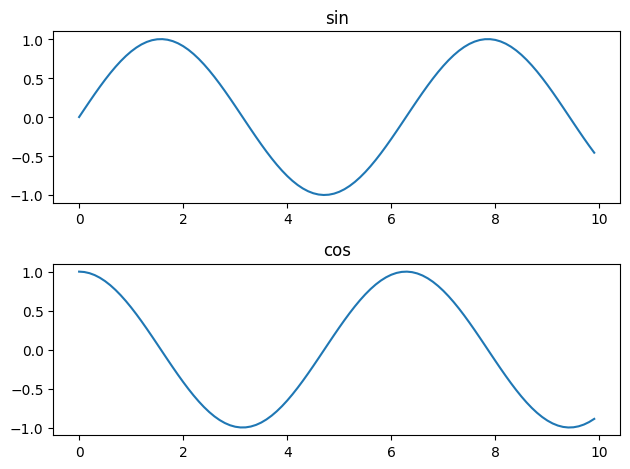

In [41]:
plt.subplot(2, 1, 1)   # (2,1) 형태 플랏의 첫 번째 자리에 그리겠다
plt.plot(x, y_sin)
plt.title('sin')

plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
plt.title('cos')

plt.tight_layout()
plt.show()

---
# 실습 Zero 마무리

| 항목 | 내용 |
|---|---|
| 0. Colab | 접속·노트 생성·GPU 설정·드라이브 마운트 |
| 1. 파이썬 기초 | print 포맷팅, for/if, enumerate, 함수, 리스트, 딕셔너리, 클래스 |
| 2. 벡터·행렬 | `np.array`, `zeros`/`ones`/`eye`/`random`, 인덱싱·슬라이싱, 원소별 연산, `dot`, `.T`, `sum(axis)`, `zeros_like` |
| 그래프 | `plt.plot`, `xlabel`/`ylabel`/`title`/`legend`, `subplot` |

### 핵심 정리
- `*` 는 **원소별 곱**, `dot` 은 **행렬 곱** — 둘을 혼동하지 말 것
- `shape` 는 항상 확인하는 습관을 들일 것 (`(2,)` 와 `(2,1)` 은 다름)
- `sum(axis=k)` 는 **k번째 축을 없앤다**